In [29]:
import os
import glob
import pickle
import json
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from scipy import sparse
from sklearn.decomposition import TruncatedSVD
from tqdm.notebook import tqdm  # Use tqdm.notebook for nice progress bars in Jupyter



from sklearn.preprocessing import normalize


from sklearn.manifold import TSNE



GRAPHS_DIR = '../../../graphs'

FILE_PATTERN = "*.pickle"     # Pattern to match your files
K_SELECTION = 20              # Number of representatives to pick
DISTANCE_METRIC = "hamming"   # "hamming" (Risk) or "jaccard" (Shape)


class ScenarioDataset:
    def __init__(self, folder_path, pattern="*.pickle"):
        self.file_paths = sorted(glob.glob(os.path.join(folder_path, pattern)))
        if not self.file_paths:
            raise ValueError(f"No files found in {folder_path} with pattern {pattern}")
            
        self.filenames = [os.path.basename(p) for p in self.file_paths]
        self.n_scenarios = len(self.file_paths)
        self.matrix = None
        self.probs = None
        
        # Build the matrix
        self._build_matrix()

    def _build_matrix(self):
        print(f"[Data] Found {self.n_scenarios} scenarios. Loading...")
        
        rows = []
        cols = []
        data = []
        
        # Map: NodeID -> Matrix Column Index
        node_to_idx = {}
        self.idx_to_node = []
        
        for i, path in enumerate(tqdm(self.file_paths, desc="Loading Graphs")):
            try:
                with open(path, "rb") as f:
                    G = pickle.load(f)
                # Assume all nodes in graph = burn scar
                nodes = list(G.nodes())
            except Exception as e:
                print(f"Error loading {path}: {e}")
                continue

            for node in nodes:
                if node not in node_to_idx:
                    node_to_idx[node] = len(self.idx_to_node)
                    self.idx_to_node.append(node)
                
                rows.append(i)
                cols.append(node_to_idx[node])
                data.append(1)

        # Create Sparse Binary Matrix (Scenarios x Nodes)
        n_unique_nodes = len(self.idx_to_node)
        self.matrix = sparse.csr_matrix(
            (data, (rows, cols)), 
            shape=(self.n_scenarios, n_unique_nodes), 
            dtype=np.uint8
        )
        
        # Default Probabilities (1/N)
        self.probs = np.full(self.n_scenarios, 1.0 / self.n_scenarios)
        
        print(f"[Data] Matrix Built. Shape: {self.matrix.shape} (Scenarios x Grid Cells)")


In [13]:

# ==========================================
# 2. Vectorized Math (Distance Engine)
# ==========================================

def compute_distances(candidates_mat, all_mat, metric, cand_sizes, all_sizes):
    """
    Computes distance between a batch of candidates and all scenarios.
    Returns matrix of shape (N_all, N_candidates)
    """
    # 1. Intersection (Matrix Dot Product)
    # (N_all, Nodes) @ (Nodes, Batch) -> (N_all, Batch)
    intersection = all_mat.dot(candidates_mat.T).toarray()
    
    if metric == "hamming":
        # Hamming = SizeA + SizeB - 2*Intersection
        # Using broadcasting to calculate pairwise difference
        dist = all_sizes[:, None] + cand_sizes[None, :] - (2 * intersection)
        return np.maximum(dist, 0) # Clip negative due to float errors
        
    elif metric == "jaccard":
        # Jaccard = 1 - (Intersection / Union)
        union = all_sizes[:, None] + cand_sizes[None, :] - intersection
        with np.errstate(divide='ignore', invalid='ignore'):
            dist = 1.0 - (intersection / union)
        dist[union == 0] = 0.0
        return dist
        
    else:
        raise ValueError("Metric must be 'hamming' or 'jaccard'")

# ==========================================
# 3. Fast Forward Selection (The Algo)
# ==========================================



# def run_ffs(dataset, k, metric="hamming"):
#     n = dataset.n_scenarios
#     # Pre-calculate sizes (number of burned nodes per scenario)
#     sizes = np.array(dataset.matrix.sum(axis=1)).flatten()
    
#     # Track min distance to nearest rep (Start at Infinity)
#     min_dists = np.full(n, np.inf)
    
#     selected_indices = []
#     selected_set = set()
    
#     print(f"\n[FFS] Selecting {k} representatives using '{metric}' distance...")
    
#     for step in range(k):
#         best_idx = -1
#         best_cost = np.inf
#         best_new_dists = None
        
#         # Identify candidates (anyone not yet selected)
#         candidates = [x for x in range(n) if x not in selected_set]
        
#         # Run in batches to save memory (e.g., check 1000 candidates at a time)
#         batch_size = 1000
#         current_global_cost = np.sum(dataset.probs * min_dists) if step > 0 else np.inf
        
#         for b_start in range(0, len(candidates), batch_size):
#             batch = candidates[b_start : b_start + batch_size]
            
#             # Compute distances for this batch
#             dists_batch = compute_distances(
#                 dataset.matrix[batch], dataset.matrix, metric, sizes[batch], sizes
#             )
            
#             # Calculate "New Cost" if we picked someone from this batch
#             # New_Min_Dist = min(Old_Min_Dist, Dist_to_Candidate)
#             new_min_dists = np.minimum(min_dists[:, None], dists_batch)
            
#             # Weighted Sum (Cost = Prob * Distance)
#             costs = np.sum(dataset.probs[:, None] * new_min_dists, axis=0)
            
#             # Find batch winner
#             local_best = np.argmin(costs)
#             if costs[local_best] < best_cost:
#                 best_cost = costs[local_best]
#                 best_idx = batch[local_best]
#                 best_new_dists = new_min_dists[:, local_best]

#         # Register the global winner for this round
#         if best_idx != -1:
#             selected_indices.append(best_idx)
#             selected_set.add(best_idx)
#             min_dists = best_new_dists
#             print(f"  Step {step+1}/{k}: Selected Scenario #{best_idx} ({dataset.filenames[best_idx]}) | Cost: {best_cost:.4f}")
#         else:
#             print("  No improvement found. Stopping early.")
#             break
            
#     return selected_indices



In [14]:
# ==========================================
# Optimized "Stochastic" Fast Forward Selection
# ==========================================

def run_ffs(dataset, k, metric="hamming", sample_size=1000, verbose=True):
    """
    Run FFS with Stochastic Sampling for speed.
    
    Args:
        sample_size (int): How many candidates to check per step. 
                           Set to 1000-2000 for a good balance of speed vs. quality.
                           Set to None to check everyone (slow).
    """
    n = dataset.n_scenarios
    sizes = np.array(dataset.matrix.sum(axis=1)).flatten()
    min_dists = np.full(n, np.inf)
    selected_indices = []
    selected_set = set()
    
    # Progress Bar
    iterator = range(k)
    if verbose:
        print(f"\n[FFS] Selecting {k} reps (checking {sample_size if sample_size else 'all'} candidates/step)...")
        # Use tqdm if available
        try:
            from tqdm.notebook import tqdm
            iterator = tqdm(range(k), desc="Selecting")
        except ImportError:
            pass

    for step in iterator:
        best_idx = -1
        best_cost = np.inf
        best_new_dists = None
        
        # 1. Identify valid candidates (not yet selected)
        # optimization: We don't need to list all 'n' if we are sampling
        if sample_size and sample_size < (n - len(selected_set)):
            # Fast random sampling without generating the full list first
            # We sample indices until we get enough non-selected ones
            # (Simplest effective way for sparse selection)
            candidates = []
            while len(candidates) < sample_size:
                batch = np.random.randint(0, n, size=sample_size)
                # Filter out already selected
                valid = [x for x in batch if x not in selected_set]
                candidates.extend(valid)
                candidates = list(set(candidates)) # Remove duplicates
            candidates = list(candidates)[:sample_size]
        else:
            # Fallback to full search if sample_size is None or dataset is small
            candidates = [x for x in range(n) if x not in selected_set]
        
        # 2. Evaluate Candidates (in batches to save memory)
        batch_limit = 1000 
        
        for b_start in range(0, len(candidates), batch_limit):
            batch = candidates[b_start : b_start + batch_limit]
            
            dists_batch = compute_distances(
                dataset.matrix[batch], dataset.matrix, metric, sizes[batch], sizes
            )
            
            # Calculate "New Cost"
            new_min_dists = np.minimum(min_dists[:, None], dists_batch)
            costs = np.sum(dataset.probs[:, None] * new_min_dists, axis=0)
            
            local_best = np.argmin(costs)
            if costs[local_best] < best_cost:
                best_cost = costs[local_best]
                best_idx = batch[local_best]
                best_new_dists = new_min_dists[:, local_best]

        # 3. Select Winner
        if best_idx != -1:
            selected_indices.append(best_idx)
            selected_set.add(best_idx)
            min_dists = best_new_dists
            
            if verbose:
                # Use print or tqdm.write
                msg = f"  Step {step+1}: Selected #{best_idx} | Cost: {best_cost:.2f}"
                try:
                    from tqdm.notebook import tqdm
                    tqdm.write(msg)
                except:
                    print(msg)
        else:
            print("  No improvement found.")
            break
            
    return selected_indices

In [30]:


def assign_and_reweight(dataset, selected_indices, metric="hamming"):
    """
    Assigns every scenario to closest rep and calculates voting power.
    """
    print("\n[Reweighting] Assigning clusters...")
    sizes = np.array(dataset.matrix.sum(axis=1)).flatten()
    
    # Calculate dist from ALL scenarios to SELECTED reps
    sel_mat = dataset.matrix[selected_indices]
    dists = compute_distances(sel_mat, dataset.matrix, metric, sizes[selected_indices], sizes)
    
    # Assign to closest (argmin across columns)
    labels = np.argmin(dists, axis=1)
    
    # Calculate new weights
    k = len(selected_indices)
    weights = np.zeros(k)
    cluster_sizes = np.zeros(k, dtype=int)
    
    for i in range(dataset.n_scenarios):
        weights[labels[i]] += dataset.probs[i]
        cluster_sizes[labels[i]] += 1
        
    return labels, weights, cluster_sizes

# ==========================================
# 4. Visualization (PCA)
# ==========================================

def plot_pca_clusters(dataset, selected_indices, labels):
    print("\n[Plotting] Running PCA reduction...")
    
    # Use TruncatedSVD (Sparse PCA)
    pca = TruncatedSVD(n_components=2, random_state=42)
    X_2d = pca.fit_transform(dataset.matrix.astype(float))
    
    plt.figure(figsize=(12, 10))
    
    # 1. Plot the Clusters (The Dots)
    unique_labels = np.unique(labels)
    # Generate distinct colors
    cmap = plt.cm.get_cmap('tab20', len(unique_labels))
    
    for i, label in enumerate(unique_labels):
        mask = (labels == label)
        plt.scatter(
            X_2d[mask, 0], X_2d[mask, 1],
            s=15, alpha=0.5, 
            color=cmap(i % 20), label=f"Group {label}"
        )
        
    # 2. Plot the Representatives (The Stars)
    rep_coords = X_2d[selected_indices]
    plt.scatter(
        rep_coords[:, 0], rep_coords[:, 1],
        s=100, c='white', edgecolors='black', marker='o', linewidth=1.5,
        label="Representatives", zorder=10
    )
    
    # Number the stars
    for i, idx in enumerate(selected_indices):
        plt.text(
            X_2d[idx, 0], X_2d[idx, 1], 
            str(i), fontsize=10, fontweight='bold', color='black'
        )

    plt.title(f"Scenario Clusters (PCA) - {len(selected_indices)} Representatives")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


In [ ]:

labels, weights, sizes = assign_and_reweight(ds, selected_idx, DISTANCE_METRIC)

print(f"{'Rep ID':<8} {'Filename':<30} {'Weight':<10} {'Cluster Size'}")
print("-" * 60)
for i, (idx, w, s) in enumerate(zip(selected_idx, weights, sizes)):
    print(f"{i:<8} {ds.filenames[idx]:<30} {w:.4f}     {s}")

GRAPHS_DIR_ABSOLUTE='/Users/ignaciagothe/Desktop/Proyecto firespread L.Murray/scenario_selection/graphs'
CURRENT_DIR='/Users/ignaciagothe/Desktop/Proyecto firespread L.Murray/scenario_selection/src/baselines/ffs/ffs_notebook2.ipynb'

GRAPHS_DIR=os.path.relpath(GRAPHS_DIR_ABSOLUTE, os.path.dirname(CURRENT_DIR))
GRAPHS_DIR


'../../../graphs'

In [17]:

ds = ScenarioDataset(GRAPHS_DIR, FILE_PATTERN)


[Data] Found 49125 scenarios. Loading...


Loading Graphs:   0%|          | 0/49125 [00:00<?, ?it/s]

[Data] Matrix Built. Shape: (49125, 306) (Scenarios x Grid Cells)


In [18]:
selected_idx = run_ffs(ds, K_SELECTION, DISTANCE_METRIC, sample_size=1000)


[FFS] Selecting 20 reps (checking 1000 candidates/step)...


Selecting:   0%|          | 0/20 [00:00<?, ?it/s]

  Step 1: Selected #25147 | Cost: 145.17
  Step 2: Selected #34462 | Cost: 120.80
  Step 3: Selected #34884 | Cost: 112.20
  Step 4: Selected #33134 | Cost: 110.48
  Step 5: Selected #33388 | Cost: 109.11
  Step 6: Selected #9369 | Cost: 108.17
  Step 7: Selected #35524 | Cost: 107.67
  Step 8: Selected #28604 | Cost: 106.57
  Step 9: Selected #35315 | Cost: 106.16
  Step 10: Selected #3470 | Cost: 105.64
  Step 11: Selected #158 | Cost: 105.44
  Step 12: Selected #16631 | Cost: 105.26
  Step 13: Selected #27823 | Cost: 105.09
  Step 14: Selected #19331 | Cost: 104.95
  Step 15: Selected #9365 | Cost: 104.81
  Step 16: Selected #41445 | Cost: 104.60
  Step 17: Selected #36024 | Cost: 104.48
  Step 18: Selected #9046 | Cost: 104.39
  Step 19: Selected #27778 | Cost: 104.30
  Step 20: Selected #33909 | Cost: 104.24


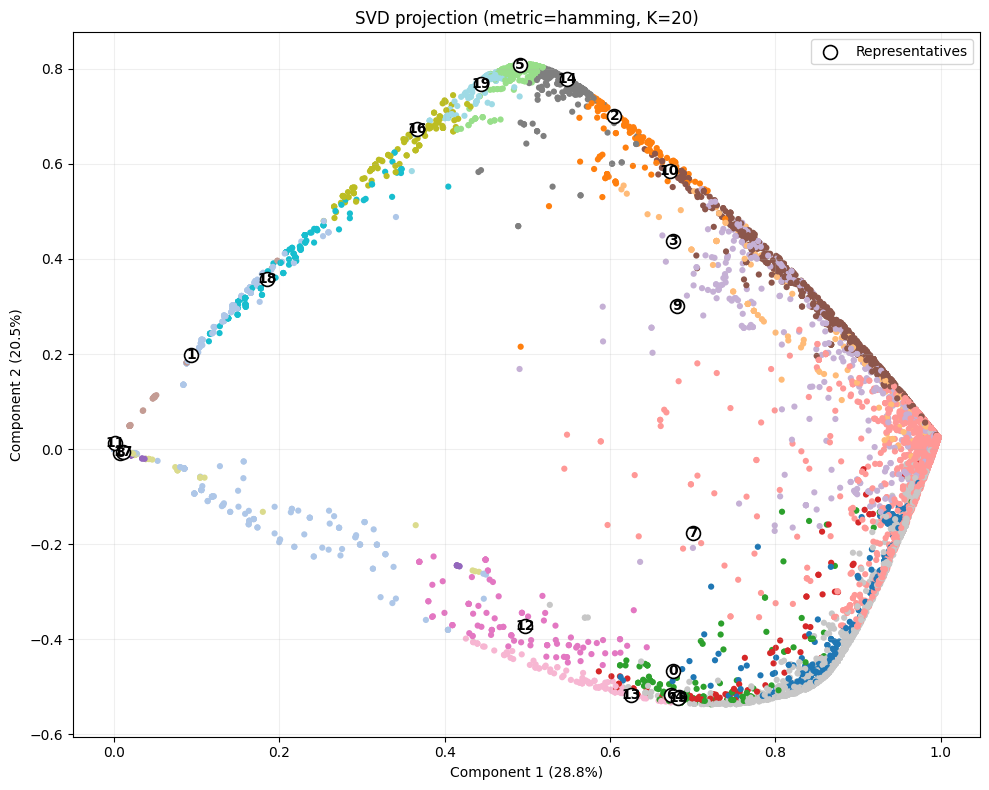

In [ ]:

def plot_svd_clusters(
    dataset,
    selected_indices,
    labels,
    max_points=20000,
    normalize_rows=True,
    random_state=42,
    title=None
):

    X = dataset.matrix  # CSR sparse (N x D)
    N = X.shape[0]

    selected_indices = np.array(selected_indices, dtype=int)
    labels = np.asarray(labels)

    rng = np.random.default_rng(random_state)
    if max_points is None or max_points >= N:
        keep = np.arange(N, dtype=int)
    else:
        keep = rng.choice(N, size=max_points, replace=False).astype(int)
        keep = np.unique(np.concatenate([keep, selected_indices]))

    X_keep = X[keep]
    if normalize_rows:
        X_keep = normalize(X_keep, norm="l2", axis=1)


    svd = TruncatedSVD(n_components=2, random_state=random_state)
    Z = svd.fit_transform(X_keep)  # (len(keep), 2)

    # Map from original index -> position in keep array
    pos = {idx: i for i, idx in enumerate(keep)}
    rep_pos = np.array([pos[i] for i in selected_indices if i in pos], dtype=int)

    # ---- 4) Plot ----
    plt.figure(figsize=(10, 8))


    plt.scatter(
        Z[:, 0], Z[:, 1],
        c=labels[keep],
        s=20,
        cmap="tab20",
        linewidths=0
    )

    plt.scatter(
        Z[rep_pos, 0], Z[rep_pos, 1],
        s=100,
        marker="o",
        facecolors="white",
        edgecolors="black",
        linewidths=1.2,
        zorder=10,
        label="Representatives"
    )

    # Number the reps 0..K-1 (in the order they were selected)
    for r, original_idx in enumerate(selected_indices):
        if original_idx in pos:
            i = pos[original_idx]
            plt.text(
                Z[i, 0], Z[i, 1],
                str(r),
                fontsize=10,
                fontweight="bold",
                ha="center",
                va="center",
                zorder=11
            )

    ev1 = getattr(svd, "explained_variance_ratio_", [np.nan, np.nan])[0]
    ev2 = getattr(svd, "explained_variance_ratio_", [np.nan, np.nan])[1]

    if title is None:
        title = f"SVD (PCA-like) 2D projection | reps={len(selected_indices)} | points shown={len(keep)}"
    plt.title(title)

    xlabel = "Component 1" if np.isnan(ev1) else f"Component 1 ({ev1:.1%})"
    ylabel = "Component 2" if np.isnan(ev2) else f"Component 2 ({ev2:.1%})"
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    plt.grid(True, alpha=0.2)
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()



def plot_umap_clusters(
    dataset,
    selected_indices,
    labels,
    distance_metric="hamming",   # your choice: "hamming" or "jaccard"
    max_points=20000,
    normalize_rows_for_hamming=True,
    n_neighbors=30,
    min_dist=0.10,
    random_state=42,
    title=None,
    savepath=None,
):
    import umap

    X = dataset.matrix  # CSR sparse (N x D)
    N = X.shape[0]
    selected_indices = np.array(selected_indices, dtype=int)
    labels = np.asarray(labels)

    # 1) choose subset (keep reps always)
    rng = np.random.default_rng(random_state)
    if max_points is None or max_points >= N:
        keep = np.arange(N, dtype=int)
    else:
        keep = rng.choice(N, size=max_points, replace=False).astype(int)
        keep = np.unique(np.concatenate([keep, selected_indices]))

    X_keep = X[keep]


    if distance_metric.lower() == "jaccard":
        umap_metric = "jaccard"
       
        X_umap = X_keep.astype(bool)
    elif distance_metric.lower() == "hamming":
        umap_metric = "manhattan"
        X_umap = X_keep.astype(np.float32)
   
        X_umap = normalize(X_umap, norm="l1", axis=1)


    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric=umap_metric,
        random_state=random_state,
        verbose=True,
    )
    Z = reducer.fit_transform(X_umap)  # (len(keep), 2)

    pos = {idx: i for i, idx in enumerate(keep)}
    rep_pos = np.array([pos[i] for i in selected_indices if i in pos], dtype=int)
    plt.figure(figsize=(10, 8))
    plt.scatter(
        Z[:, 0], Z[:, 1],
        c=labels[keep],
        s=10,
        cmap="tab20",
        linewidths=0
    )
    plt.scatter(
        Z[rep_pos, 0], Z[rep_pos, 1],
        s=100,
        marker="o",
        facecolors="white",
        edgecolors="black",
        linewidths=1.2,
        zorder=10,
        label="Representatives"
    )

    for r, original_idx in enumerate(selected_indices):
        if original_idx in pos:
            i = pos[original_idx]
            plt.text(
                Z[i, 0], Z[i, 1],
                str(r),
                fontsize=10,
                fontweight="bold",
                ha="center",
                va="center",
                zorder=11
            )

    if title is None:
        title = f"UMAP 2D (metric={umap_metric}) | reps={len(selected_indices)} | points shown={len(keep)}"
    plt.title(title)
    plt.xlabel("UMAP-1")
    plt.ylabel("UMAP-2")
    plt.grid(True, alpha=0.2)
    plt.legend(loc="best")
    plt.tight_layout()

    plt.show()

def plot_tsne_clusters(
    dataset,
    selected_indices,
    labels,
    distance_metric="hamming",     # "hamming" or "jaccard" (affects normalization choices)
    max_points=12000,              # keep this <= ~20000 on a laptop
    svd_dim=50,                    # 30-100 is typical
    perplexity=30,                 # 20-50 typical; must be < (n_points-1)/3
    random_state=42,
    title=None,
    savepath=None,
):
    X = dataset.matrix  # CSR sparse (N x D)
    N = X.shape[0]
    selected_indices = np.array(selected_indices, dtype=int)
    labels = np.asarray(labels)

    # 1) subsample points (always include reps)
    rng = np.random.default_rng(random_state)
    if max_points is None or max_points >= N:
        keep = np.arange(N, dtype=int)
    else:
        keep = rng.choice(N, size=max_points, replace=False).astype(int)
        keep = np.unique(np.concatenate([keep, selected_indices]))

    X_keep = X[keep]
    X_keep = normalize(X_keep, norm="l2", axis=1)

    svd = TruncatedSVD(n_components=svd_dim, random_state=random_state)
    Y = svd.fit_transform(X_keep).astype(np.float32)  # (n_keep, svd_dim)

    Y = normalize(Y, norm="l2", axis=1)

    tsne = TSNE(
        n_components=2,
        perplexity=min(perplexity, max(5, (len(keep) - 1) // 3)),
        init="pca",
        learning_rate="auto",
        random_state=random_state,
        verbose=1
    )
    Z = tsne.fit_transform(Y) 


    pos = {idx: i for i, idx in enumerate(keep)}
    rep_pos = np.array([pos[i] for i in selected_indices if i in pos], dtype=int)

    # 5) plot
    plt.figure(figsize=(10, 8))
    plt.scatter(
        Z[:, 0], Z[:, 1],
        c=labels[keep],
        s=10,
        cmap="tab20",
        linewidths=0
    )

    plt.scatter(
        Z[rep_pos, 0], Z[rep_pos, 1],
        s=100,
        marker="o",
        facecolors="white",
        edgecolors="black",
        linewidths=1.2,
        zorder=10,
        label="Representatives"
    )

    for r, original_idx in enumerate(selected_indices):
        if original_idx in pos:
            i = pos[original_idx]
            plt.text(Z[i, 0], Z[i, 1], str(r),
                     fontsize=10, fontweight="bold",
                     ha="center", va="center", zorder=11)

    if title is None:
        title = f"t-SNE 2D (SVD→tSNE) | reps={len(selected_indices)} | points shown={len(keep)}"
    plt.title(title)
    plt.xlabel("t-SNE-1")
    plt.ylabel("t-SNE-2")
    plt.grid(True, alpha=0.2)
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()




/Users/ignaciagothe/Desktop/Proyecto firespread L.Murray/scenario_selection/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP(metric='manhattan', n_jobs=1, n_neighbors=30, random_state=42, verbose=True)
Tue Feb 10 00:23:06 2026 Construct fuzzy simplicial set
Tue Feb 10 00:23:06 2026 Finding Nearest Neighbors
Tue Feb 10 00:23:06 2026 Building RP forest with 14 trees
Tue Feb 10 00:23:23 2026 metric NN descent for 15 iterations
	 1  /  15
	 2  /  15
	Stopping threshold met -- exiting after 2 iterations
Tue Feb 10 00:23:49 2026 Finished Nearest Neighbor Search
Tue Feb 10 00:23:49 2026 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Tue Feb 10 00:24:39 2026 Finished embedding


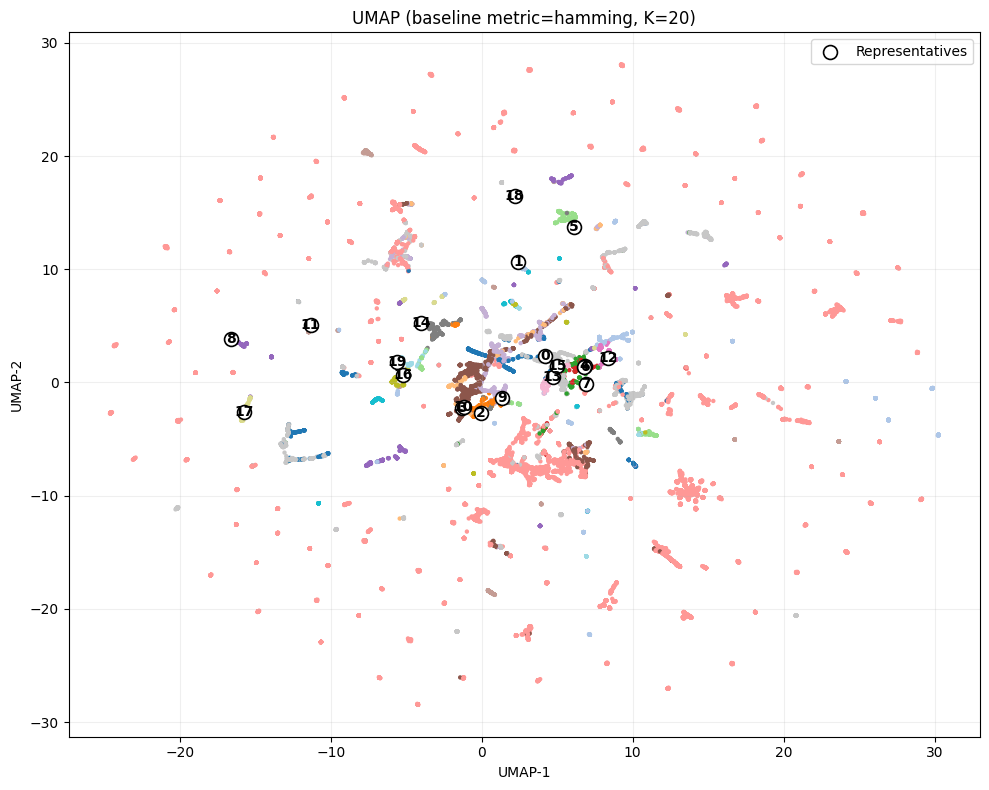

In [ ]:
plot_pca_clusters(ds, selected_idx, labels)

plot_svd_clusters(
    ds,
    selected_idx,
    labels,
    max_points=15000,          # increase if you want (e.g., 30000)
    normalize_rows=True,       # keep True unless you have a reason not to
    random_state=42,
    title=f"SVD projection (metric={DISTANCE_METRIC}, K={len(selected_idx)})",
    savepath=None              # or "svd_clusters.png"
)

plot_umap_clusters(
    ds,
    selected_idx,
    labels,
    distance_metric=DISTANCE_METRIC,  # "hamming" or "jaccard"
    max_points=30000,
    n_neighbors=30,
    min_dist=0.10,
    random_state=42,
    title=f"UMAP (baseline metric={DISTANCE_METRIC}, K={len(selected_idx)})",
)


[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 30007 samples in 0.000s...
[t-SNE] Computed neighbors for 30007 samples in 0.241s...
[t-SNE] Computed conditional probabilities for sample 1000 / 30007
[t-SNE] Computed conditional probabilities for sample 2000 / 30007
[t-SNE] Computed conditional probabilities for sample 3000 / 30007
[t-SNE] Computed conditional probabilities for sample 4000 / 30007
[t-SNE] Computed conditional probabilities for sample 5000 / 30007
[t-SNE] Computed conditional probabilities for sample 6000 / 30007
[t-SNE] Computed conditional probabilities for sample 7000 / 30007
[t-SNE] Computed conditional probabilities for sample 8000 / 30007
[t-SNE] Computed conditional probabilities for sample 9000 / 30007
[t-SNE] Computed conditional probabilities for sample 10000 / 30007
[t-SNE] Computed conditional probabilities for sample 11000 / 30007
[t-SNE] Computed conditional probabilities for sample 12000 / 30007
[t-SNE] Computed conditional probabilities for sam

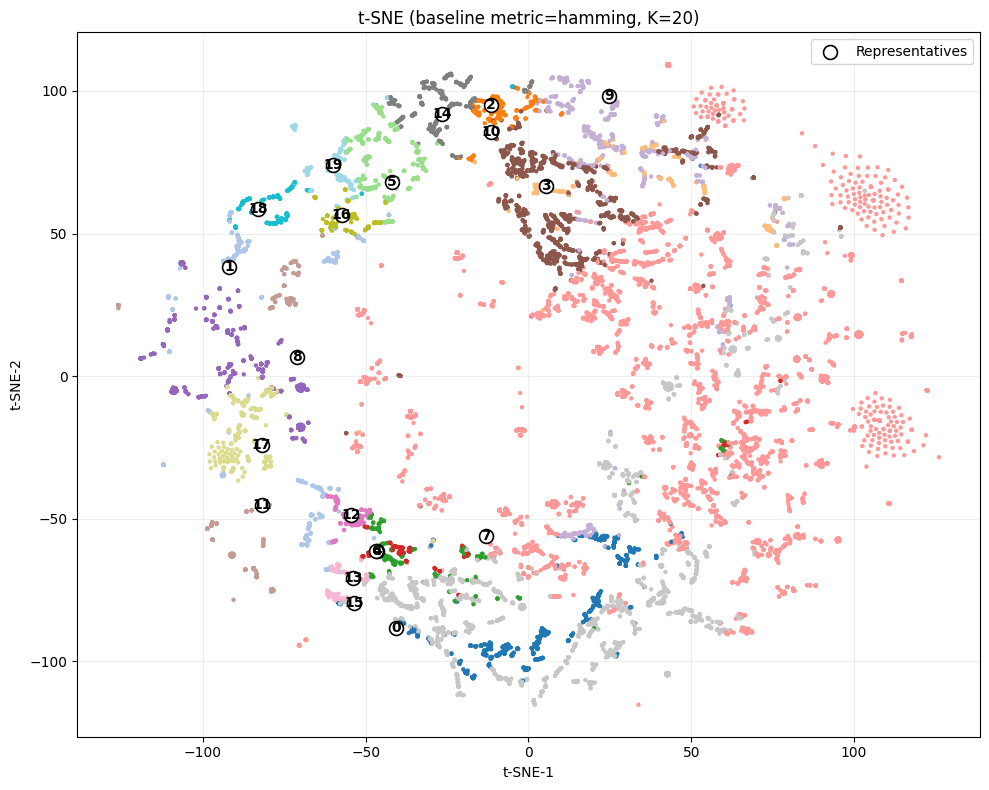

In [48]:

plot_tsne_clusters(
    ds,
    selected_idx,
    labels,
    distance_metric=DISTANCE_METRIC,
    max_points=30000,
    svd_dim=50,
    perplexity=30,
    title=f"t-SNE (baseline metric={DISTANCE_METRIC}, K={len(selected_idx)})"
)


# k=100


In [ ]:

labels, weights, sizes = assign_and_reweight(ds, selected_idx, DISTANCE_METRIC)

print(f"{'Rep ID':<8} {'Filename':<30} {'Weight':<10} {'Cluster Size'}")
print("-" * 60)
for i, (idx, w, s) in enumerate(zip(selected_idx, weights, sizes)):
    print(f"{i:<8} {ds.filenames[idx]:<30} {w:.4f}     {s}")

In [51]:
selected_idx = run_ffs(ds, 100, DISTANCE_METRIC, sample_size=2000)
labels, weights, sizes = assign_and_reweight(ds, selected_idx, DISTANCE_METRIC)
print(f"{'Rep ID':<8} {'Filename':<30} {'Weight':<10} {'Cluster Size'}")
print("-" * 60)
for i, (idx, w, s) in enumerate(zip(selected_idx, weights, sizes)):
    print(f"{i:<8} {ds.filenames[idx]:<30} {w:.4f}     {s}")




[FFS] Selecting 100 reps (checking 2000 candidates/step)...


Selecting:   0%|          | 0/100 [00:00<?, ?it/s]

  Step 1: Selected #36780 | Cost: 143.31
  Step 2: Selected #27843 | Cost: 126.37
  Step 3: Selected #25598 | Cost: 113.31
  Step 4: Selected #33928 | Cost: 108.69
  Step 5: Selected #2713 | Cost: 107.59
  Step 6: Selected #42578 | Cost: 106.87
  Step 7: Selected #24865 | Cost: 106.47
  Step 8: Selected #3470 | Cost: 105.82
  Step 9: Selected #26095 | Cost: 105.44
  Step 10: Selected #25195 | Cost: 105.25
  Step 11: Selected #18171 | Cost: 105.10
  Step 12: Selected #4020 | Cost: 104.97
  Step 13: Selected #18631 | Cost: 104.84
  Step 14: Selected #4122 | Cost: 104.73
  Step 15: Selected #25559 | Cost: 104.64
  Step 16: Selected #26559 | Cost: 104.47
  Step 17: Selected #710 | Cost: 104.38
  Step 18: Selected #28640 | Cost: 104.31
  Step 19: Selected #27967 | Cost: 104.16
  Step 20: Selected #24756 | Cost: 104.09
  Step 21: Selected #33286 | Cost: 104.02
  Step 22: Selected #16638 | Cost: 103.97
  Step 23: Selected #19225 | Cost: 103.92
  Step 24: Selected #33582 | Cost: 103.87
  Step 


[Plotting] Running PCA reduction...


/var/folders/hw/gkt_y4dn77j710wygt9bsrjm0000gn/T/ipykernel_34125/4263143751.py:42: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(unique_labels))
/var/folders/hw/gkt_y4dn77j710wygt9bsrjm0000gn/T/ipykernel_34125/4263143751.py:72: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


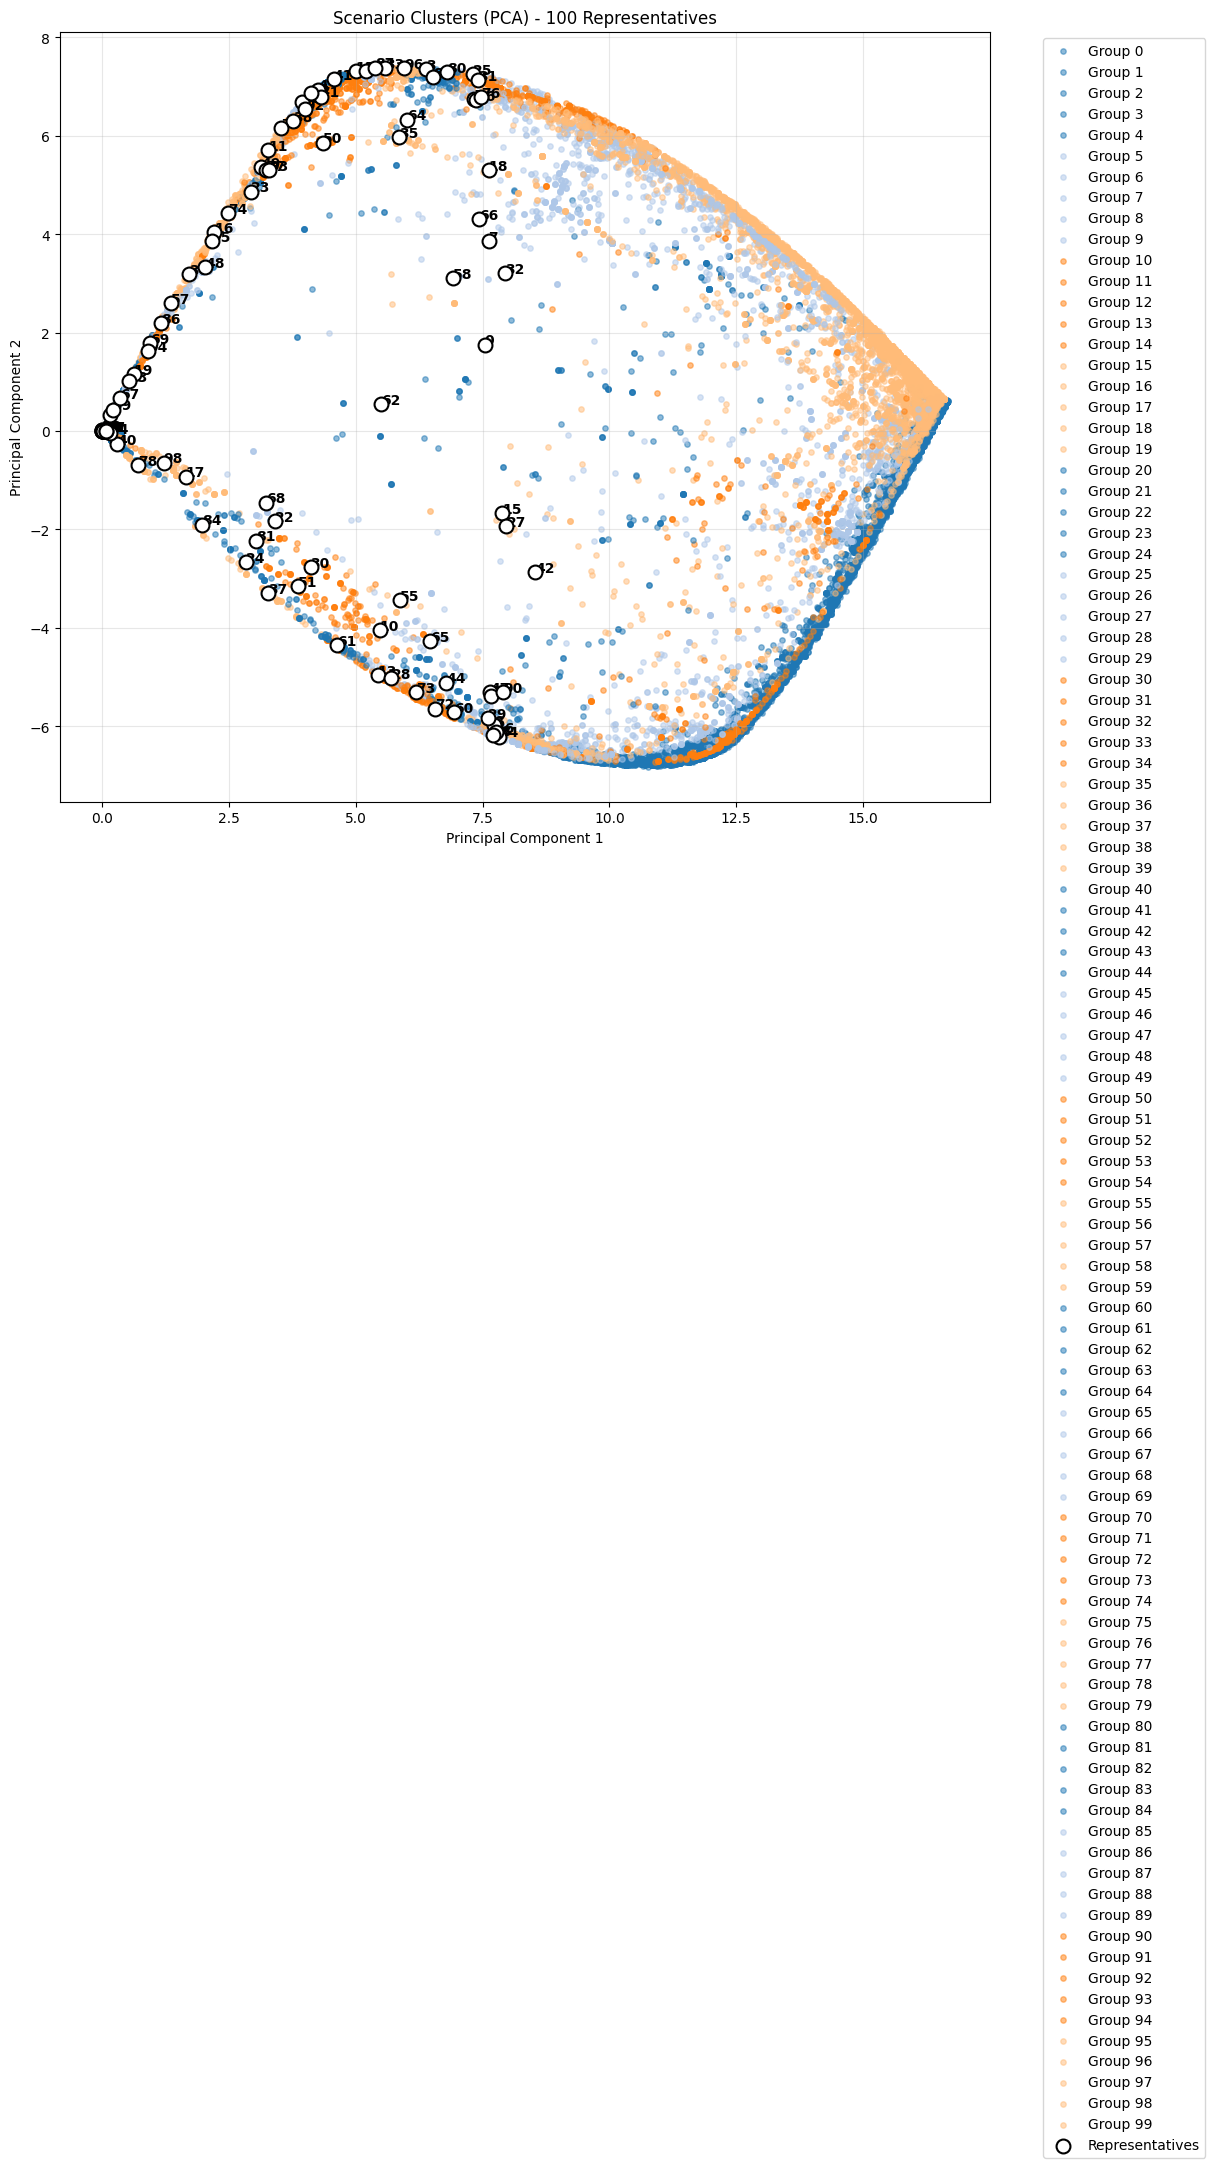

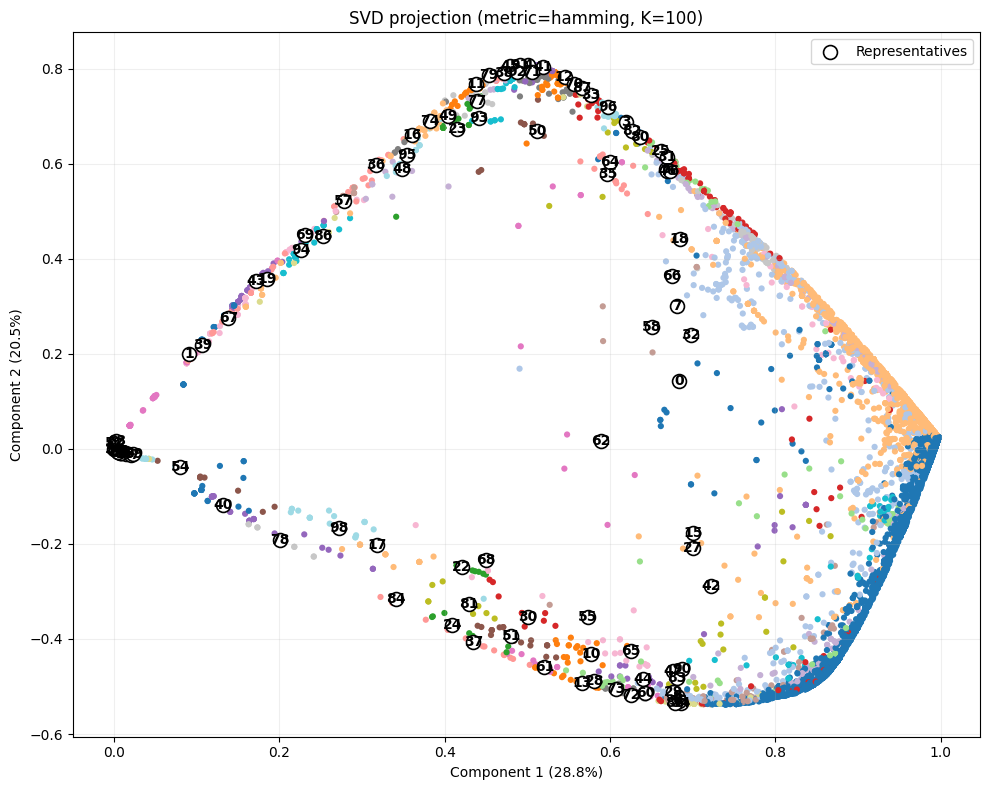

/Users/ignaciagothe/Desktop/Proyecto firespread L.Murray/scenario_selection/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP(metric='manhattan', n_jobs=1, n_neighbors=30, random_state=42, verbose=True)
Tue Feb 10 00:48:23 2026 Construct fuzzy simplicial set
Tue Feb 10 00:48:23 2026 Finding Nearest Neighbors
Tue Feb 10 00:48:23 2026 Building RP forest with 14 trees
Tue Feb 10 00:48:39 2026 metric NN descent for 15 iterations
	 1  /  15
	 2  /  15
	Stopping threshold met -- exiting after 2 iterations
Tue Feb 10 00:49:04 2026 Finished Nearest Neighbor Search
Tue Feb 10 00:49:04 2026 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Tue Feb 10 00:49:54 2026 Finished embedding


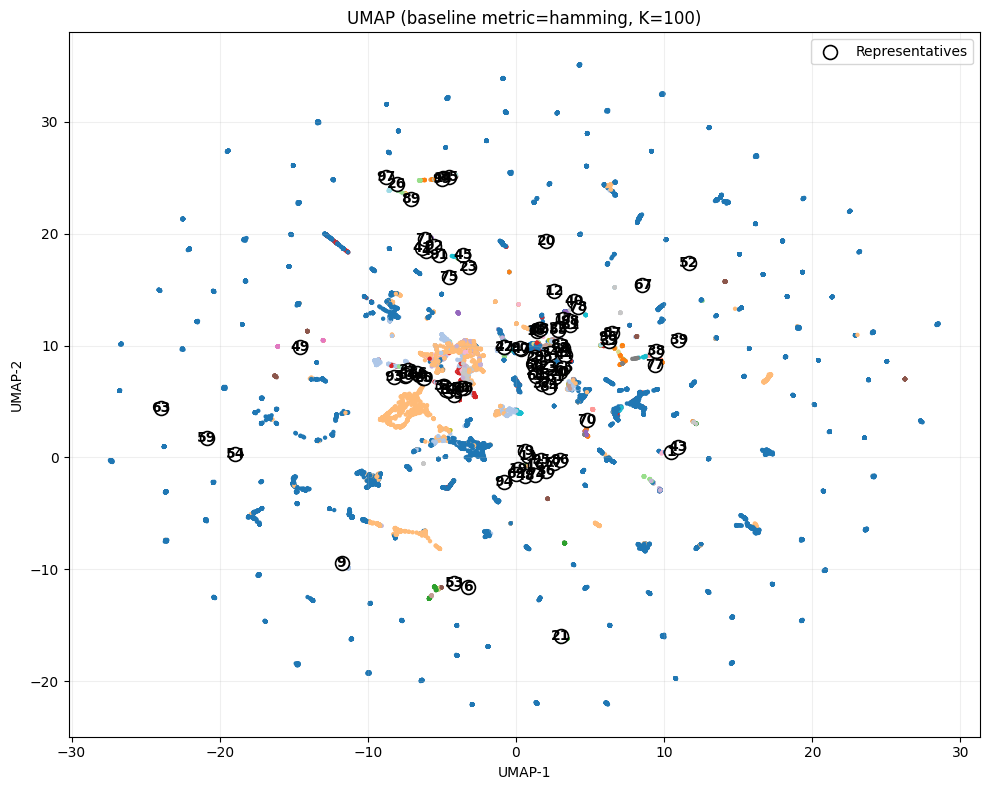

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 30041 samples in 0.000s...
[t-SNE] Computed neighbors for 30041 samples in 0.214s...
[t-SNE] Computed conditional probabilities for sample 1000 / 30041
[t-SNE] Computed conditional probabilities for sample 2000 / 30041
[t-SNE] Computed conditional probabilities for sample 3000 / 30041
[t-SNE] Computed conditional probabilities for sample 4000 / 30041
[t-SNE] Computed conditional probabilities for sample 5000 / 30041
[t-SNE] Computed conditional probabilities for sample 6000 / 30041
[t-SNE] Computed conditional probabilities for sample 7000 / 30041
[t-SNE] Computed conditional probabilities for sample 8000 / 30041
[t-SNE] Computed conditional probabilities for sample 9000 / 30041
[t-SNE] Computed conditional probabilities for sample 10000 / 30041
[t-SNE] Computed conditional probabilities for sample 11000 / 30041
[t-SNE] Computed conditional probabilities for sample 12000 / 30041
[t-SNE] Computed conditional probabilities for sam

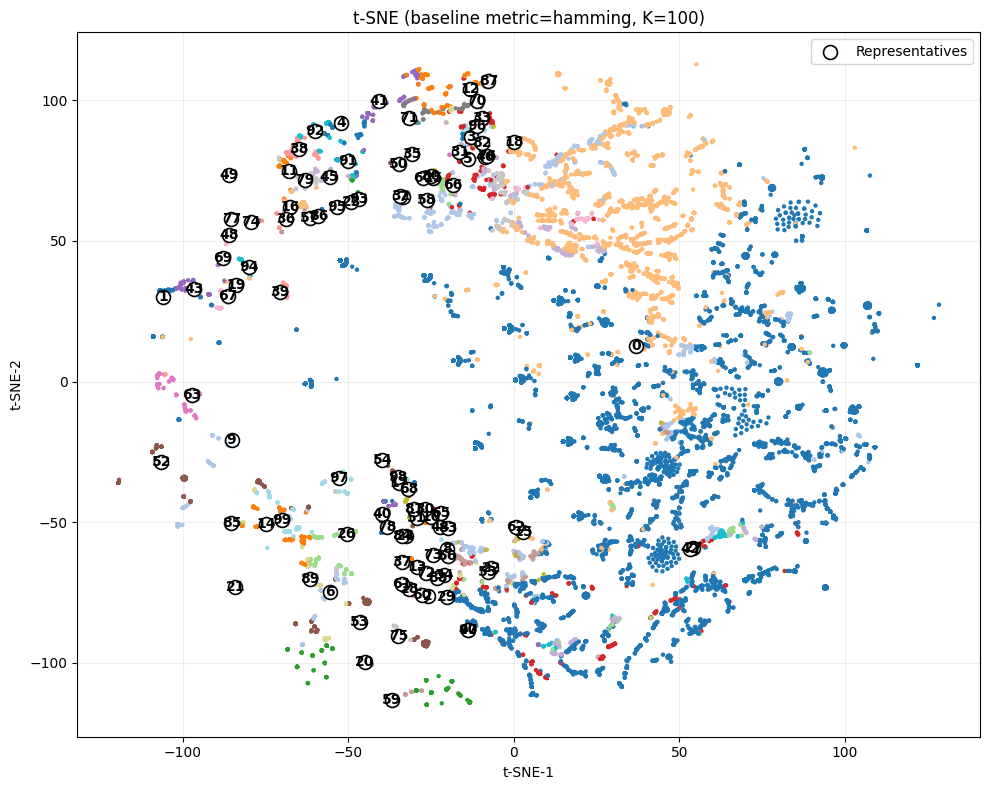

In [52]:
plot_pca_clusters(ds, selected_idx, labels)

plot_svd_clusters(
    ds,
    selected_idx,
    labels,
    max_points=15000,          # increase if you want (e.g., 30000)
    normalize_rows=True,       # keep True unless you have a reason not to
    random_state=42,
    title=f"SVD projection (metric={DISTANCE_METRIC}, K={len(selected_idx)})",
    savepath=None              # or "svd_clusters.png"
)

plot_umap_clusters(
    ds,
    selected_idx,
    labels,
    distance_metric=DISTANCE_METRIC,  # "hamming" or "jaccard"
    max_points=30000,
    n_neighbors=30,
    min_dist=0.10,
    random_state=42,
    title=f"UMAP (baseline metric={DISTANCE_METRIC}, K={len(selected_idx)})",
)

plot_tsne_clusters(
    ds,
    selected_idx,
    labels,
    distance_metric=DISTANCE_METRIC,
    max_points=30000,
    svd_dim=50,
    perplexity=30,
    title=f"t-SNE (baseline metric={DISTANCE_METRIC}, K={len(selected_idx)})"
)
